<a href="https://colab.research.google.com/github/Sairakesh08/Ensuring-Skin-Cancer/blob/main/model_Buliding_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install -q keras-tuner
!pip install opencv-python
!pip install tensorflow

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from tqdm import tqdm
import tensorflow as tf
from PIL import Image
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, EfficientNetB0, VGG16
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Conv2D, MaxPooling2D, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
import warnings
from google.colab import drive
import seaborn as sns
import matplotlib.patches as patches
from google.colab import files
from tensorflow.keras.preprocessing import image
warnings.filterwarnings('ignore')

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
dataset_path = "/content/drive/MyDrive/dataset_binary_balanced_oversampled"

In [6]:
dataset_path = "/content/drive/MyDrive/dataset_binary_balanced_oversampled"

classes = os.listdir(dataset_path)
print("Classes:", classes)

class_counts = {}
for cls in classes:
    class_dir = os.path.join(dataset_path, cls)
    class_counts[cls] = len(os.listdir(class_dir))

print("\nImage counts per class:")
for cls, count in class_counts.items():
    print(f"{cls}: {count} images")

Classes: ['benign', 'malignant']

Image counts per class:
benign: 15991 images
malignant: 15991 images


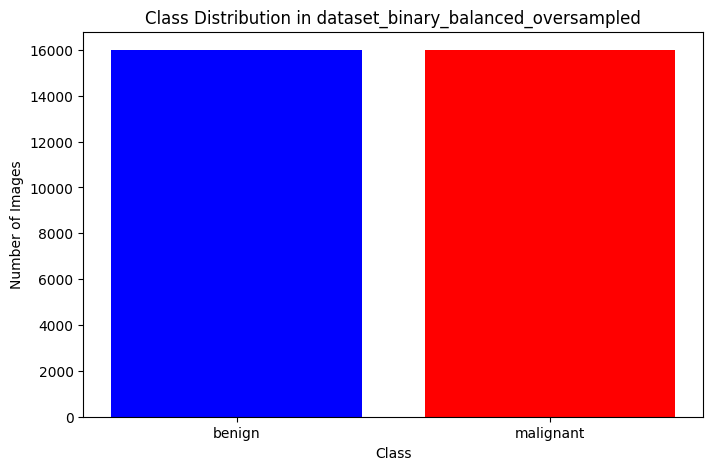

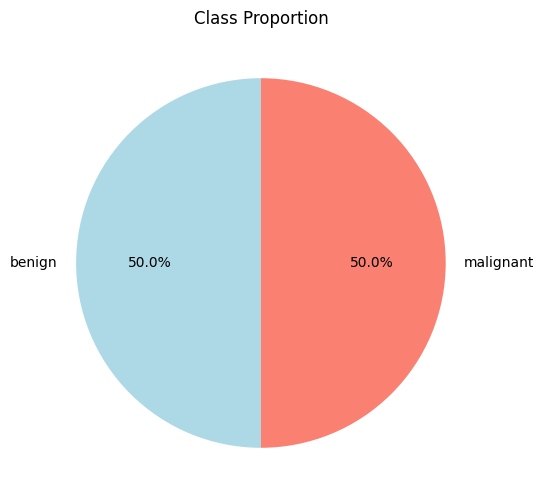

In [7]:
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values(), color=['blue', 'red'])
plt.title("Class Distribution in dataset_binary_balanced_oversampled")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

plt.figure(figsize=(6, 6))
plt.pie(class_counts.values(), labels=class_counts.keys(), autopct='%1.1f%%',
        colors=['lightblue', 'salmon'], startangle=90)
plt.title("Class Proportion")
plt.show()

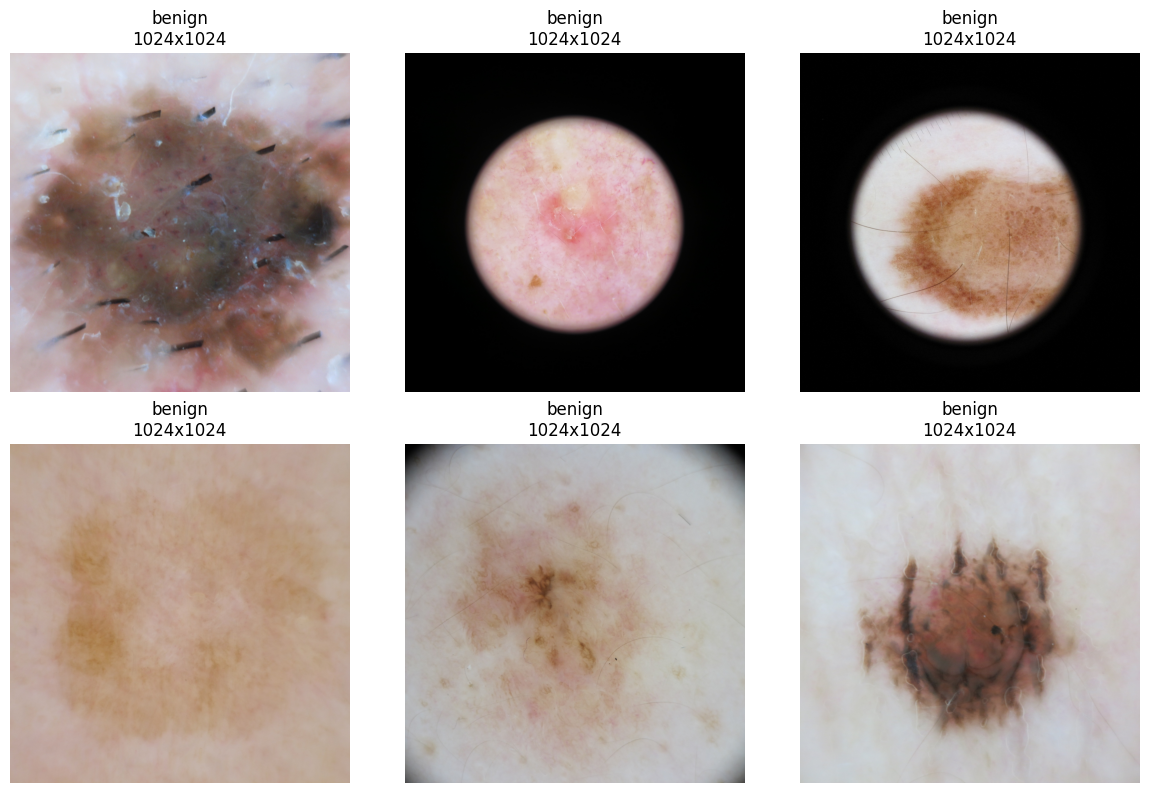

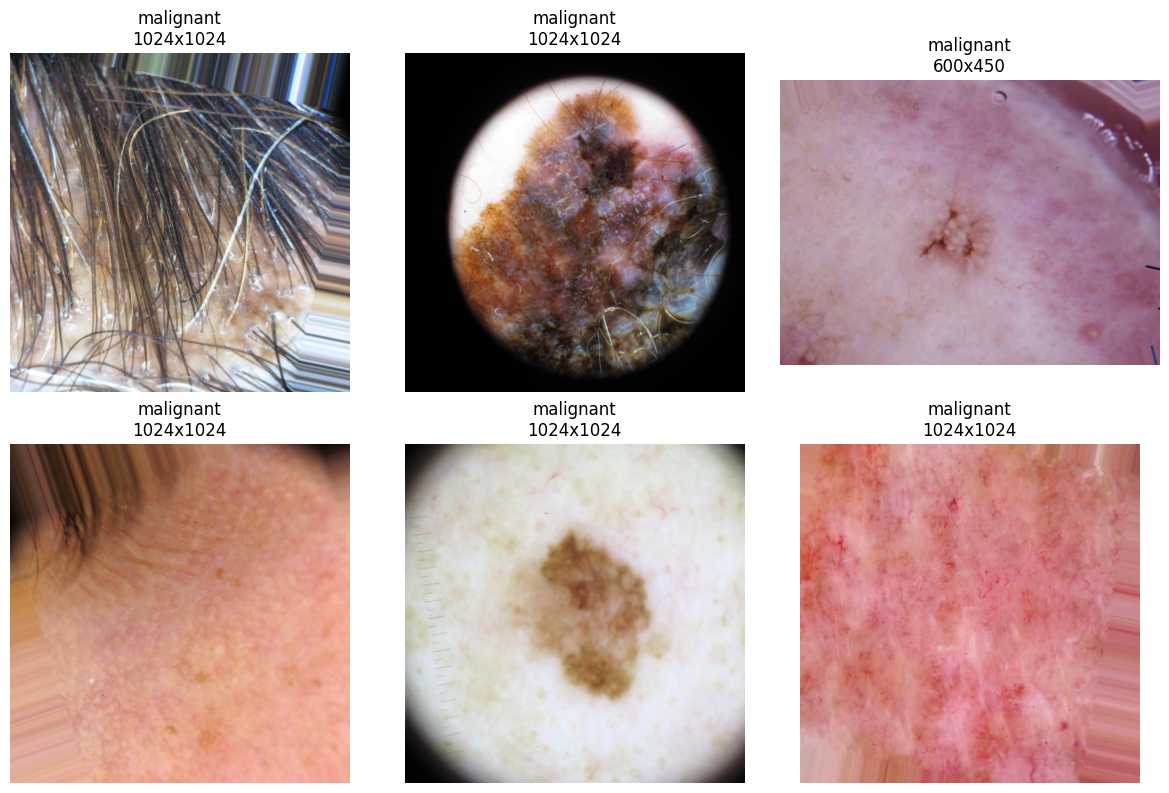

In [8]:
def plot_samples(class_name, num_samples=6):
    class_dir = os.path.join(dataset_path, class_name)
    images = os.listdir(class_dir)[:num_samples]

    plt.figure(figsize=(12, 8))
    for i, img_name in enumerate(images):
        img_path = os.path.join(class_dir, img_name)
        img = Image.open(img_path)

        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(f"{class_name}\n{img.size[0]}x{img.size[1]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Display samples
plot_samples("benign")
plot_samples("malignant")

In [9]:
dataset_path = "/content/drive/MyDrive/dataset_binary_balanced_oversampled"
npy_save_path = os.path.join(dataset_path, "npy_files")
os.makedirs(npy_save_path, exist_ok=True)

raw_path = os.path.join(npy_save_path, "images_raw.npy")
cleaned_path = os.path.join(npy_save_path, "images_cleaned.npy")
labels_path = os.path.join(npy_save_path, "labels.npy")

def remove_hair(img_array):
    grayscale = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(1, (17, 17))
    blackhat = cv2.morphologyEx(grayscale, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    inpainted = cv2.inpaint(img_array, mask, 1, cv2.INPAINT_TELEA)
    return inpainted

if os.path.exists(raw_path) and os.path.exists(cleaned_path) and os.path.exists(labels_path):
    print("NPY files found. Skipping preprocessing...")
    images_raw = np.load(raw_path)
    images_cleaned = np.load(cleaned_path)
    labels = np.load(labels_path)
else:
    print("NPY files not found. Running hair removal and preprocessing...")

    IMAGE_SIZE = (224, 224)
    images_raw = []
    images_cleaned = []
    labels = []

    classes = os.listdir(dataset_path)
    classes = [cls for cls in classes if os.path.isdir(os.path.join(dataset_path, cls))]  # skip npy_files folder

    for label, class_name in enumerate(classes):
        class_dir = os.path.join(dataset_path, class_name)
        image_files = os.listdir(class_dir)

        for img_name in tqdm(image_files):
            img_path = os.path.join(class_dir, img_name)
            try:
                img = Image.open(img_path).convert("RGB")
                img = img.resize(IMAGE_SIZE)
                img_array = np.array(img)

                images_raw.append(img_array)
                images_cleaned.append(remove_hair(img_array))
                labels.append(label)
            except Exception as e:
                print(f"Skipped {img_path}: {e}")

    images_raw = np.array(images_raw)
    images_cleaned = np.array(images_cleaned)
    labels = np.array(labels)

    np.save(raw_path, images_raw)
    np.save(cleaned_path, images_cleaned)
    np.save(labels_path, labels)
    print("NPY files saved!")


NPY files not found. Running hair removal and preprocessing...


100%|██████████| 15991/15991 [14:24<00:00, 18.49it/s]
0it [00:00, ?it/s]


NPY files saved!


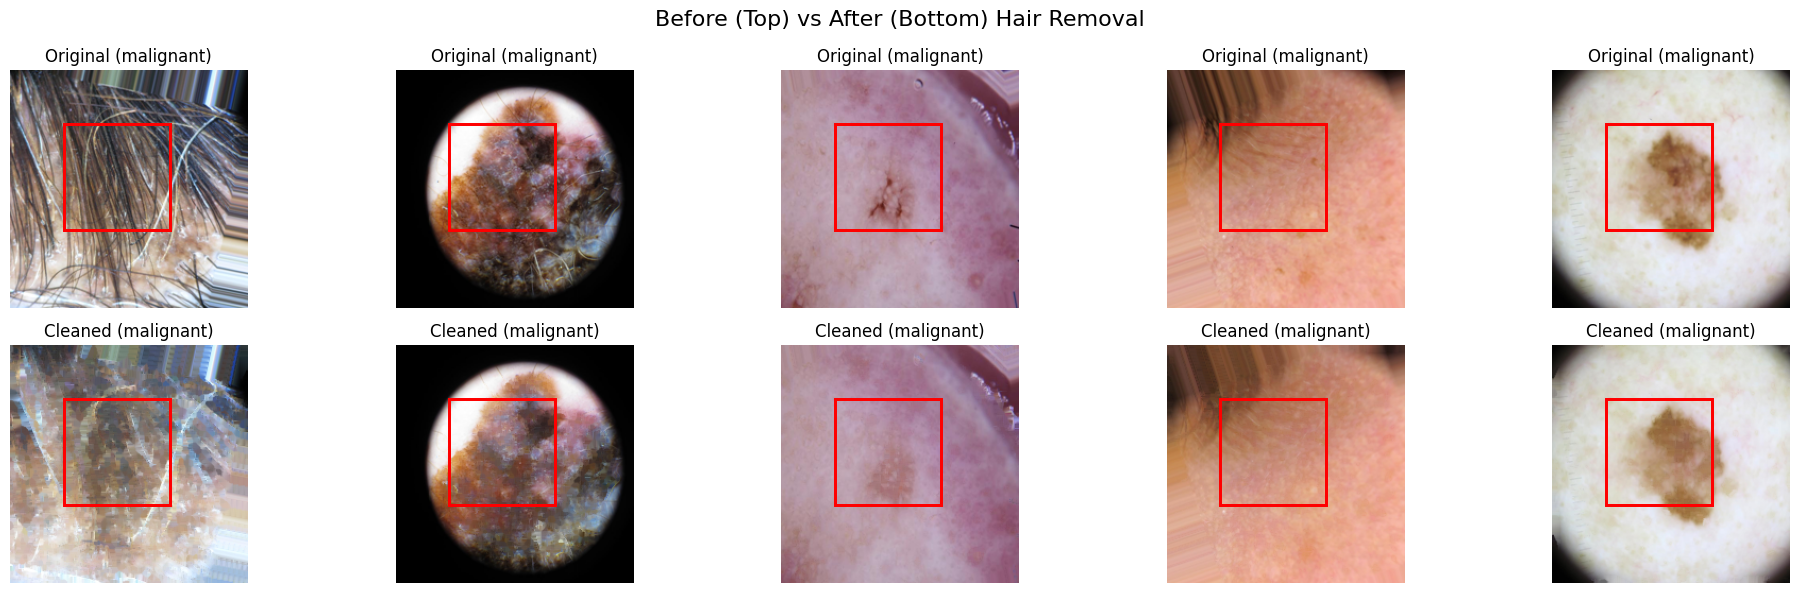

In [10]:
def show_sample_images_with_highlight(images_raw, images_cleaned, labels, class_names=["benign", "malignant"], num_images=5):
    fig, axs = plt.subplots(2, num_images, figsize=(20, 6))
    fig.suptitle("Before (Top) vs After (Bottom) Hair Removal", fontsize=16)

    for class_label in [0, 1]:
        class_indices = np.where(labels == class_label)[0][:num_images]

        for i, idx in enumerate(class_indices):
            axs[0, i].imshow(images_raw[idx])
            axs[0, i].set_title(f"Original ({class_names[class_label]})")
            axs[0, i].axis('off')

            axs[1, i].imshow(images_cleaned[idx])
            axs[1, i].set_title(f"Cleaned ({class_names[class_label]})")
            axs[1, i].axis('off')

            rect1 = patches.Rectangle((50, 50), 100, 100, linewidth=2, edgecolor='r', facecolor='none')
            rect2 = patches.Rectangle((50, 50), 100, 100, linewidth=2, edgecolor='r', facecolor='none')
            axs[0, i].add_patch(rect1)
            axs[1, i].add_patch(rect2)

    plt.tight_layout()
    plt.show()

show_sample_images_with_highlight(images_raw, images_cleaned, labels)

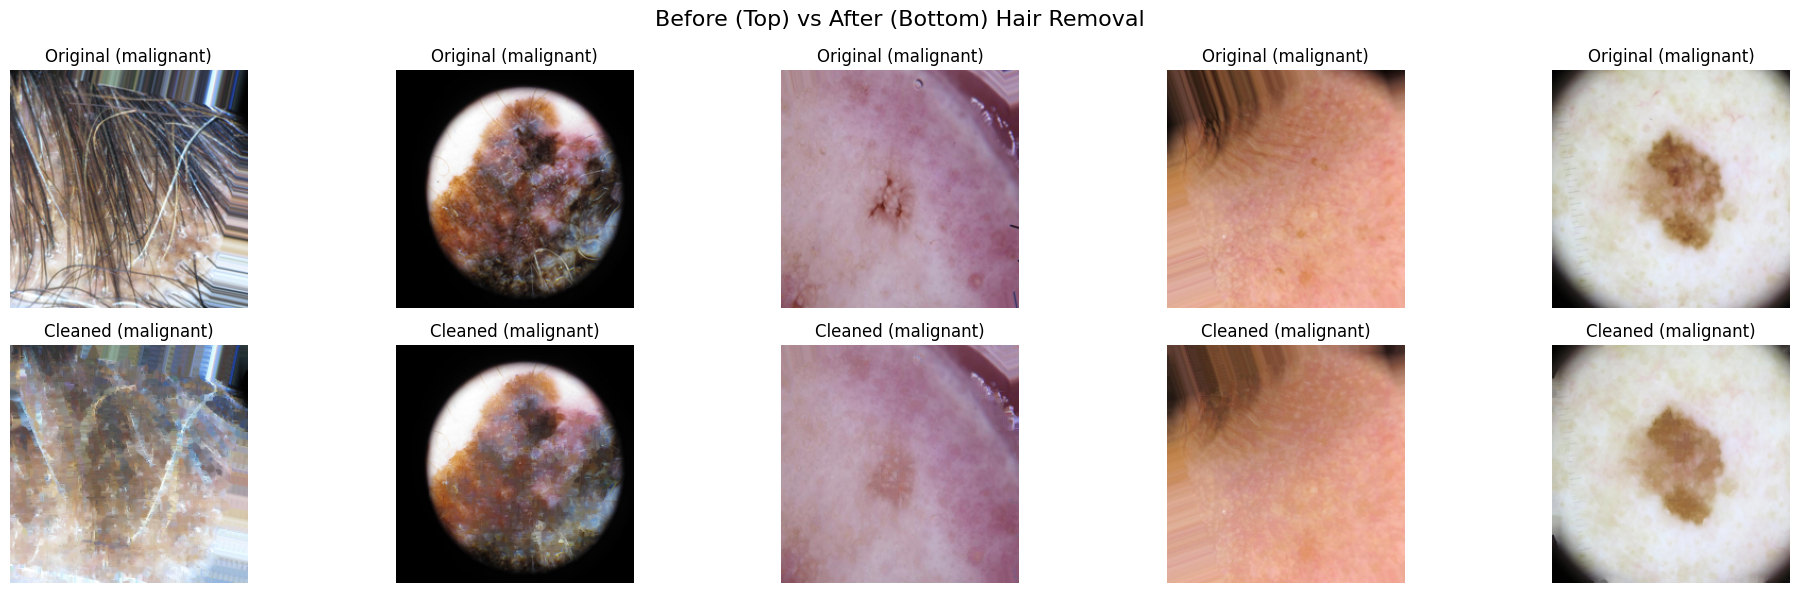

In [11]:
def show_sample_images(images_raw, images_cleaned, labels, class_names=["benign", "malignant"], num_images=5):
    fig, axs = plt.subplots(2, num_images, figsize=(20, 6))
    fig.suptitle("Before (Top) vs After (Bottom) Hair Removal", fontsize=16)

    for class_label in [0, 1]:
        class_indices = np.where(labels == class_label)[0][:num_images]

        for i, idx in enumerate(class_indices):
            axs[0, i].imshow(images_raw[idx])
            axs[0, i].set_title(f"Original ({class_names[class_label]})")
            axs[0, i].axis('off')

            axs[1, i].imshow(images_cleaned[idx])
            axs[1, i].set_title(f"Cleaned ({class_names[class_label]})")
            axs[1, i].axis('off')

    plt.tight_layout()
    plt.show()

# Display samples
show_sample_images(images_raw, images_cleaned, labels)


In [12]:
from sklearn.model_selection import train_test_split

images_cleaned = images_cleaned / 255.0

X_train, X_val, y_train, y_val = train_test_split(
    images_cleaned, labels, test_size=0.2, stratify=labels, random_state=42
)

print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}")


Training samples: 25585, Validation samples: 6397


# CNN Model

In [13]:
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

# Class weights

In [ ]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(zip(np.unique(y_train), class_weights_array))
print("Class Weights:", class_weights)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop]
)


Class Weights: {np.int64(0): np.float64(1.0000390869293307), np.int64(1): np.float64(0.9999609161260065)}
Epoch 1/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 355s 441ms/step - accuracy: 0.6567 - loss: 0.6066 - val_accuracy: 0.7074 - val_loss: 0.5426
Epoch 2/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 336s 420ms/step - accuracy: 0.7125 - loss: 0.5427 - val_accuracy: 0.7396 - val_loss: 0.5097
Epoch 3/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 333s 416ms/step - accuracy: 0.7328 - loss: 0.5169 - val_accuracy: 0.7402 - val_loss: 0.5084
Epoch 4/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 337s 422ms/step - accuracy: 0.7464 - loss: 0.4979 - val_accuracy: 0.7499 - val_loss: 0.4940
Epoch 5/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 338s 422ms/step - accuracy: 0.7595 - loss: 0.4868 - val_accuracy: 0.7564 - val_loss: 0.5024
Epoch 6/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 338s 423ms/step - accuracy: 0.7612 - loss: 0.4803 - val_accuracy: 0.7741 - val_loss: 0.4658
Epoch 7/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 335s 418ms/step - accuracy: 0.7759 - loss: 0.4533 - val_accura

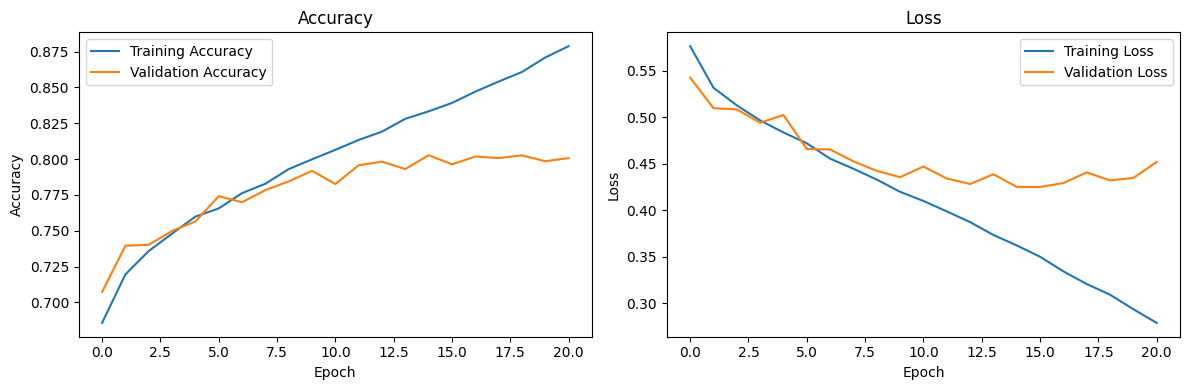

In [32]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')

plt.tight_layout()
plt.show()


200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step
Classification Report:
              precision    recall  f1-score   support

      benign       0.78      0.82      0.80      3199
   malignant       0.81      0.77      0.79      3198

    accuracy                           0.80      6397
   macro avg       0.80      0.80      0.80      6397
weighted avg       0.80      0.80      0.80      6397

Confusion Matrix:
[[2630  569]
 [ 734 2464]]
ROC-AUC Score: 0.8862


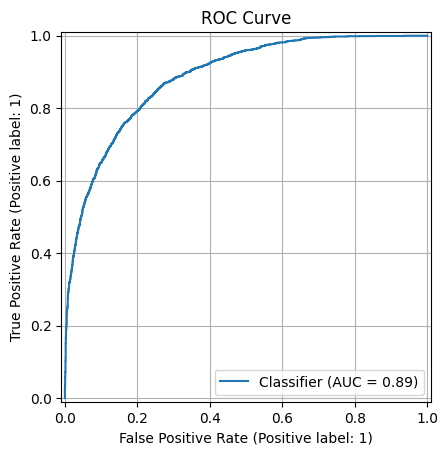

In [31]:
# Predict on validation set
y_pred_prob = cnn_model.predict(X_val).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

# Classification report
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=["benign", "malignant"]))

# Confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_val, y_pred)
print(cm)

# ROC-AUC
roc_auc = roc_auc_score(y_val, y_pred_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot ROC curve
RocCurveDisplay.from_predictions(y_val, y_pred_prob)
plt.title("ROC Curve")
plt.grid(True)
plt.show()


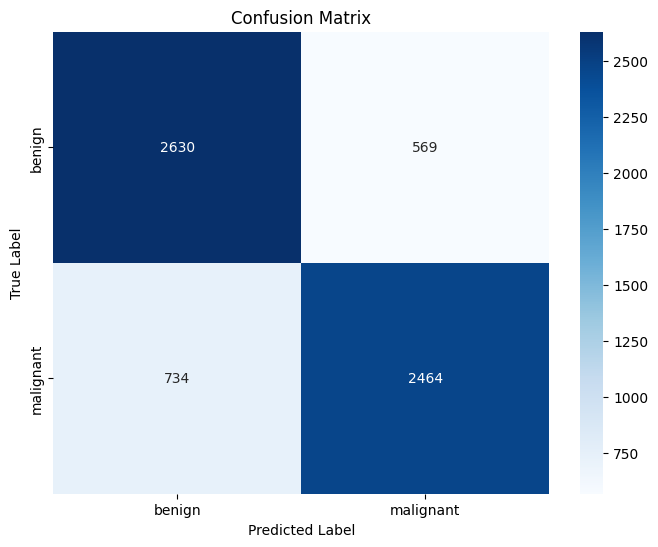

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["benign", "malignant"],
            yticklabels=["benign", "malignant"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


# Save the model

In [33]:
model_save_path = "/content/drive/MyDrive/dataset_binary_balanced_oversampled/cnn_model.keras"
cnn_model.save(model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to /content/drive/MyDrive/dataset_binary_balanced_oversampled/cnn_model.keras


In [34]:
from tensorflow.keras.models import load_model
loaded_model = load_model("/content/drive/MyDrive/dataset_binary_balanced_oversampled/cnn_model.keras")

# Evaluate the model and print test loss and accuracy


In [35]:
loss, accuracy = cnn_model.evaluate(X_val, y_val, verbose=0)
print(f"CNN Model - Validation Loss: {loss:.4f}")
print(f"CNN Model - Validation Accuracy: {accuracy:.4f}")

CNN Model - Validation Loss: 0.4249
CNN Model - Validation Accuracy: 0.7963


#ResNet Model

In [21]:
base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))
base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

resnet_model = Model(inputs=base_model.input, outputs=output)

resnet_model.compile(optimizer=Adam(learning_rate=1e-4),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

resnet_model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(zip(np.unique(y_train), class_weights_array))
print("Class Weights:", class_weights)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [23]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_resnet = resnet_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/40
800/800 ━━━━━━━━━━━━━━━━━━━━ 451s 556ms/step - accuracy: 0.5108 - loss: 0.7199 - val_accuracy: 0.5317 - val_loss: 0.6874
Epoch 2/40
800/800 ━━━━━━━━━━━━━━━━━━━━ 434s 543ms/step - accuracy: 0.5523 - loss: 0.6853 - val_accuracy: 0.6106 - val_loss: 0.6791
Epoch 3/40
800/800 ━━━━━━━━━━━━━━━━━━━━ 431s 538ms/step - accuracy: 0.5676 - loss: 0.6796 - val_accuracy: 0.6555 - val_loss: 0.6728
Epoch 4/40
800/800 ━━━━━━━━━━━━━━━━━━━━ 432s 539ms/step - accuracy: 0.5885 - loss: 0.6730 - val_accuracy: 0.6075 - val_loss: 0.6680
Epoch 5/40
800/800 ━━━━━━━━━━━━━━━━━━━━ 428s 535ms/step - accuracy: 0.5960 - loss: 0.6688 - val_accuracy: 0.5656 - val_loss: 0.6668
Epoch 6/40
800/800 ━━━━━━━━━━━━━━━━━━━━ 433s 541ms/step - accuracy: 0.6036 - loss: 0.6623 - val_accuracy: 0.6173 - val_loss: 0.6565
Epoch 7/40
800/800 ━━━━━━━━━━━━━━━━━━━━ 434s 542ms/step - accuracy: 0.6185 - loss: 0.6590 - val_accuracy: 0.6426 - val_loss: 0.6516
Epoch 8/40
800/800 ━━━━━━━━━━━━━━━━━━━━ 430s 537ms/step - accuracy: 0.6276 -

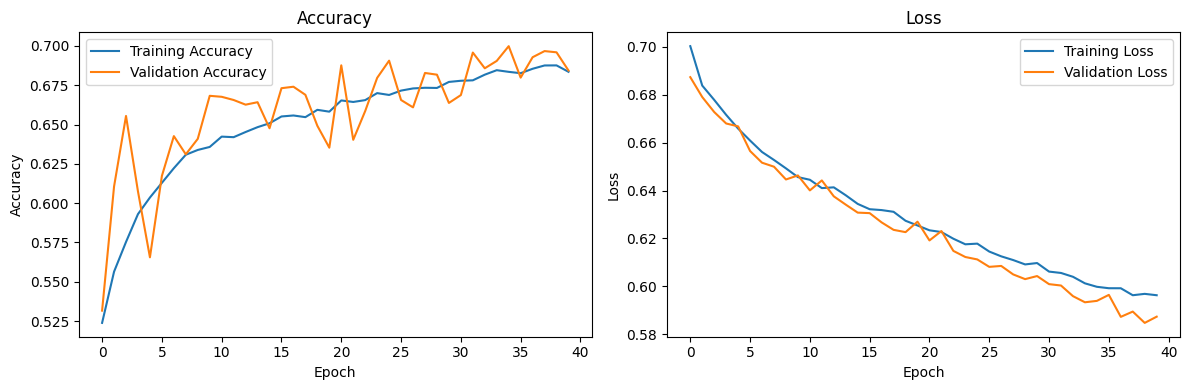

In [24]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_resnet.history['accuracy'], label='Training Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history_resnet.history['loss'], label='Training Loss')
plt.plot(history_resnet.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')

plt.tight_layout()
plt.show()

200/200 ━━━━━━━━━━━━━━━━━━━━ 95s 457ms/step
Classification Report - ResNet50:
              precision    recall  f1-score   support

      benign       0.68      0.74      0.71      3199
   malignant       0.71      0.65      0.68      3198

    accuracy                           0.70      6397
   macro avg       0.70      0.70      0.70      6397
weighted avg       0.70      0.70      0.70      6397

Confusion Matrix:
[[2364  835]
 [1110 2088]]
ROC-AUC Score: 0.7755


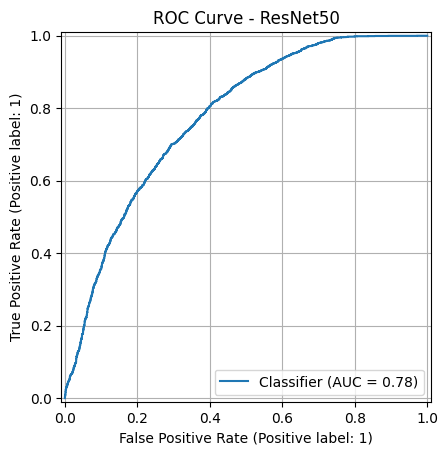

In [25]:
y_pred_resnet_prob = resnet_model.predict(X_val).ravel()
y_pred_resnet = (y_pred_resnet_prob > 0.5).astype(int)

print("Classification Report - ResNet50:")
print(classification_report(y_val, y_pred_resnet, target_names=["benign", "malignant"]))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_resnet))

resnet_auc = roc_auc_score(y_val, y_pred_resnet_prob)
print(f"ROC-AUC Score: {resnet_auc:.4f}")

RocCurveDisplay.from_predictions(y_val, y_pred_resnet_prob)
plt.title("ROC Curve - ResNet50")
plt.grid(True)
plt.show()


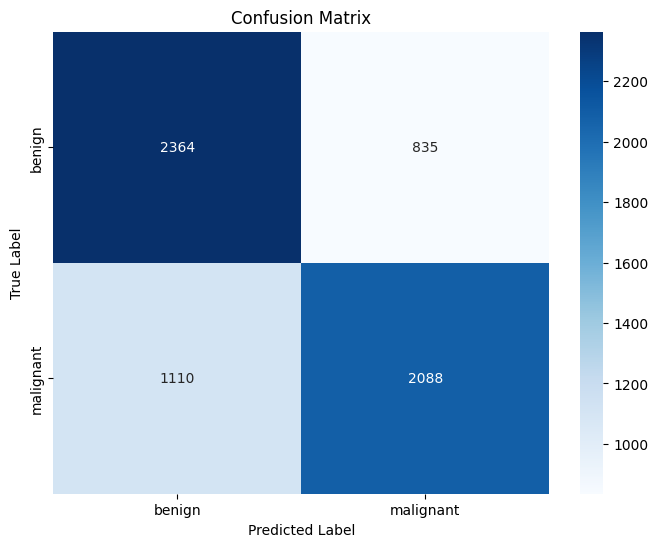

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred_resnet)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["benign", "malignant"],
            yticklabels=["benign", "malignant"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [27]:
model_save_path = "/content/drive/MyDrive/dataset_binary_balanced_oversampled/resnet_model.keras"
resnet_model.save(model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to /content/drive/MyDrive/dataset_binary_balanced_oversampled/resnet_model.keras


In [28]:
loss, accuracy = resnet_model.evaluate(X_val, y_val, verbose=0)
print(f"ResNet Model - Validation Loss: {loss:.4f}")
print(f"ResNet Model - Validation Accuracy: {accuracy:.4f}")

ResNet Model - Validation Loss: 0.5848
ResNet Model - Validation Accuracy: 0.6960


# ResNet50 Fine-tune

In [36]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

resnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Fine-tune
history_finetuned = resnet_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop]
)
resnet_model.save('/content/drive/MyDrive/dataset_binary_balanced_oversampled/fine_tuned_resnet50_skin_cancer.keras')
print("Fine-tuned ResNet50 model saved to Drive.")

Epoch 1/40
234/800 ━━━━━━━━━━━━━━━━━━━━ 7:13 765ms/step - accuracy: 0.6990 - loss: 0.5837

KeyboardInterrupt: 

In [ ]:
# Evaluate the model
loss, accuracy = resnet_model.evaluate(X_val, y_val, verbose=0)
print(f"FineTune_ResNet Model - Validation Loss: {loss:.4f}")
print(f"FineTune_ResNet Model - Validation Accuracy: {accuracy:.4f}")

In [ ]:
y_pred_ft_prob = resnet_model.predict(X_val).ravel()
y_pred_ft = (y_pred_ft_prob > 0.5).astype(int)

print("Classification Report - ResNet50 (Fine-Tuned):")
print(classification_report(y_val, y_pred_ft, target_names=["benign", "malignant"]))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_ft))

ft_auc = roc_auc_score(y_val, y_pred_ft_prob)
print(f"ROC-AUC Score (Fine-Tuned): {ft_auc:.4f}")

RocCurveDisplay.from_predictions(y_val, y_pred_ft_prob)
plt.title("ROC Curve - ResNet50 (Fine-Tuned)")
plt.grid(True)
plt.show()


In [ ]:
cm = confusion_matrix(y_val, y_pred_ft)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["benign", "malignant"],
            yticklabels=["benign", "malignant"])
plt.title("Confusion Matrix - ResNet50 (Fine-Tuned)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# EfficientNetB0 model


In [ ]:
base_model_eff = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))
base_model_eff.trainable = False

# 2. Add new classification head
x = base_model_eff.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

# 3. Create the model
eff_model = Model(inputs=base_model_eff.input, outputs=output)

# 4. Compile
eff_model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# 5. Show model summary
eff_model.summary()

In [ ]:
# 6. Compute class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(zip(np.unique(y_train), class_weights_array))

# 7. Set early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 8. Train the model
history_eff = eff_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop]
)

# 9. Save model
model_save_path_eff = '/content/drive/MyDrive/dataset_binary_balanced_oversampled/efficientnetb0_model.keras'
eff_model.save(model_save_path_eff)
print(f"EfficientNetB0 model saved at: {model_save_path_eff}")


In [ ]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

eff_model = Model(inputs=base_model.input, outputs=output)


base_model.trainable = True

fine_tune_at = len(base_model.layers) - 50
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Frozen layers: {fine_tune_at}, Trainable layers: {len(base_model.layers) - fine_tune_at}")

eff_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_eff_ft = eff_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop]
)

fine_tuned_model_path = '/content/drive/MyDrive/dataset_binary_balanced_oversampled/efficientnetb0_finetuned_model.keras'
eff_model.save(fine_tuned_model_path)
print(f"Fine-tuned EfficientNetB0 model saved at: {fine_tuned_model_path}")

In [ ]:
fine_tuned_model_path = '/content/drive/MyDrive/dataset_binary_balanced_oversampled/efficientnetb0_finetuned_model.keras'
eff_model_ft = load_model(fine_tuned_model_path)
print(f"Model loaded successfully from: {fine_tuned_model_path}")

loss, accuracy = eff_model_ft.evaluate(X_val, y_val, verbose=0)
print(f"Fine-tuned EfficientNetB0 - Validation Loss: {loss:.4f}")
print(f"Fine-tuned EfficientNetB0 - Validation Accuracy: {accuracy:.4f}")

In [ ]:
y_pred_eff_ft_prob = eff_model_ft.predict(X_val).ravel()

y_pred_eff_ft = (y_pred_eff_ft_prob > 0.5).astype(int)

print("\nClassification Report - EfficientNetB0 (Fine-Tuned):")
print(classification_report(y_val, y_pred_eff_ft, target_names=["benign", "malignant"]))

# 7. Confusion Matrix
cm = confusion_matrix(y_val, y_pred_eff_ft)
print("\nConfusion Matrix:")
print(cm)

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["benign", "malignant"],
            yticklabels=["benign", "malignant"])
plt.title("Confusion Matrix - EfficientNetB0 (Fine-Tuned)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
roc_auc_eff_ft = roc_auc_score(y_val, y_pred_eff_ft_prob)
print(f"\nROC-AUC Score (Fine-Tuned): {roc_auc_eff_ft:.4f}")

RocCurveDisplay.from_predictions(y_val, y_pred_eff_ft_prob)
plt.title("ROC Curve - EfficientNetB0 (Fine-Tuned)")
plt.grid(True)
plt.show()

# Results

In [ ]:
from google.colab import files
model_path = '/content/drive/MyDrive/dataset_binary_balanced_oversampled/fine_tuned_resnet50_skin_cancer.keras'
model = load_model(model_path)
print(f"Model loaded successfully from: {model_path}")

uploaded = files.upload()
image_name = list(uploaded.keys())[0]
print(f"Uploaded image: {image_name}")

def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

# 5. Prediction function
def predict_image(img_path):
    img_array = preprocess_image(img_path)
    prediction = model.predict(img_array)
    confidence = prediction[0][0]
    if confidence > 0.5:
        result = "Malignant (Cancerous)"
    else:
        result = "Benign (Non-Cancerous)"
    return result, confidence, img_array

# 6. Grad-CAM function
def grad_cam(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)[0]
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

# 7. Overlay Grad-CAM on original image
def overlay_heatmap(img_path, heatmap):
    img = cv2.imread(img_path)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)
    return superimposed_img

# 8. Run prediction and Grad-CAM
result, confidence, img_array = predict_image(image_name)

# Plotting
img = image.load_img(image_name, target_size=(224, 224))
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {result}\nConfidence: {confidence:.4f}")

last_conv_layer_name = "conv5_block3_out"
heatmap = grad_cam(img_array, model, last_conv_layer_name)
superimposed_img = overlay_heatmap(image_name, heatmap)

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM Heatmap")
plt.axis('off')

plt.tight_layout()
plt.show()